<a href="https://colab.research.google.com/github/OutisAyo/council-classifier-/blob/main/notebooks/07_model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Automated Classification and Prioritisation of Local Council Service Requests in the UK
## Notebook 07 Model Comparison and Final Selection (Department Prediction)

**Author:** Fashina Fuad Ayomide  
**MSc Data Science, University of South Wales**

This notebook compares the four classification models built in Notebooks 03-06 and selects the best-performing model for department prediction, based primarily on F1-macro due to class imbalance.

## Mounting Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing the libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Loading the comparison results

In [4]:
results_path = '/content/drive/MyDrive/council-classifier/processed/model_results.csv'
results_df = pd.read_csv(results_path)
results_df

,model,accuracy,f1_macro,f1_weighted
0,Naive Bayes,0.997956,0.979528,0.997955
1,Logistic Regression,0.998585,0.991498,0.998584
2,Random Forest,0.998663,0.992122,0.998662
3,XGBoost,0.998604,0.991088,0.998604


## Visualising model performance

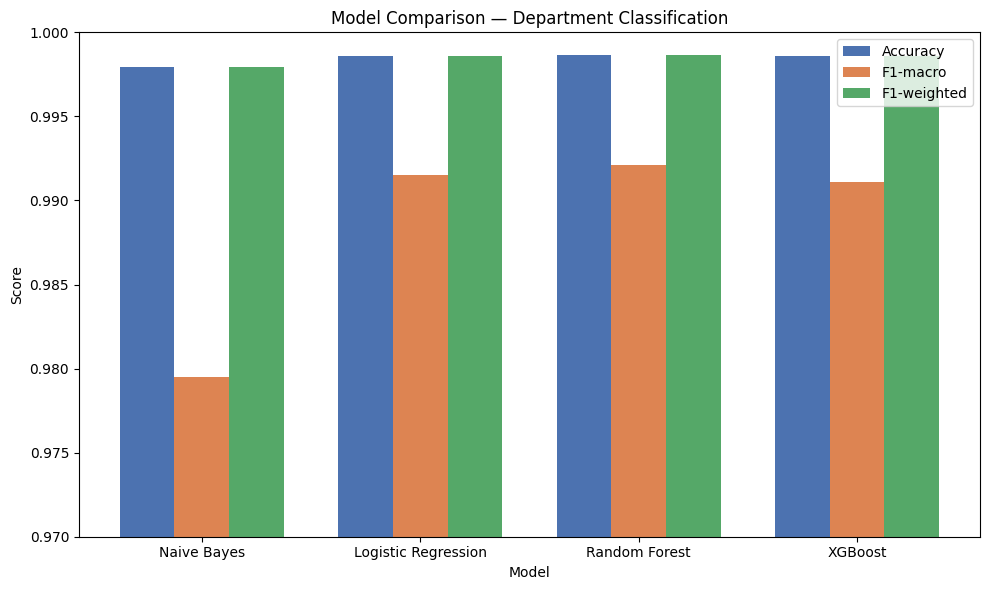

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(results_df))
width = 0.25

ax.bar(x - width, results_df['accuracy'], width, label='Accuracy', color='#4C72B0')
ax.bar(x, results_df['f1_macro'], width, label='F1-macro', color='#DD8452')
ax.bar(x + width, results_df['f1_weighted'], width, label='F1-weighted', color='#55A868')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Department Classification')
ax.set_xticks(x)
ax.set_xticklabels(results_df['model'])
ax.set_ylim(0.97, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

## Identifying the best model by F1-macro

F1-macro is prioritised over accuracy because of the severe class imbalance in department distribution (Waste Management = 76% of records). F1-macro weights all classes equally, better reflecting real-world performance across minority departments.

In [6]:
best_model_row = results_df.loc[results_df['f1_macro'].idxmax()]
print("Best performing model (by F1-macro):")
print(best_model_row)

Best performing model (by F1-macro):
model          Random Forest
accuracy            0.998663
f1_macro            0.992122
f1_weighted         0.998662
Name: 2, dtype: object


## Summary of findings

- All four models achieved very high accuracy (>99.7%) and F1-macro (>97.9%)
- **Random Forest** achieved the highest F1-macro score (0.9921), making it the selected model for department classification
- The margin between Logistic Regression, Random Forest, and XGBoost is small (within 0.01 F1-macro), while Naive Bayes trails more noticeably
- Diminishing returns from increasingly sophisticated models (and XGBoost's slight underperformance relative to Random Forest) are consistent with the earlier diagnostic finding that department classification is largely resolved by category/complaint vocabulary alone, since 99.93% of records come from category codes with over 90% single-department dominance
- **Random Forest is selected as the department classification model** going forward, to be used in the decision support layer and dashboard

## Saving the final selected model

We retrain Random Forest on the full pipeline and save it, so it can be loaded directly by the dashboard without retraining.

In [7]:
import joblib
import os
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier

processed_dir = '/content/drive/MyDrive/council-classifier/processed'
models_dir = '/content/drive/MyDrive/council-classifier/models'

os.makedirs(models_dir, exist_ok=True)

X_train = np.load(f'{processed_dir}/X_train.npy', allow_pickle=True)
y_dept_train = np.load(f'{processed_dir}/y_dept_train.npy', allow_pickle=True)

department_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(max_features=1500)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1))
])

department_pipeline.fit(X_train, y_dept_train)

joblib.dump(department_pipeline, f'{models_dir}/department_pipeline_rf.pkl')

print("Department classification pipeline saved to:", models_dir)

Department classification pipeline saved to: /content/drive/MyDrive/council-classifier/models
